In [1]:
import os 

file_dir = "/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot"

robots = []
tasks = ["threading_d0"]
depth = False

files = [file for file in os.listdir(file_dir) if all(robot in file for robot in robots) and all(task in file for task in tasks) if ("depth" in file) == depth]
files

['threading_d0_sawyer.hdf5',
 'threading_d0_iiwa.hdf5',
 'threading_d0_panda.hdf5',
 'threading_d0_ur5e.hdf5']

In [2]:
import h5py
from tqdm import tqdm 
from random import randint 

frames = {}
for file in tqdm(files): 
    with h5py.File(os.path.join(file_dir, file), "r") as hf: 
        data = hf["data"]
        print(f"Number of demos: {len(data.keys())}")
        
        idx_demo = randint(0, len(data.keys())-1)
        demo = data[f"demo_{idx_demo}"]
        n_steps = demo["actions"][()].shape[0]
        
        idx_obs = randint(0, n_steps-1)
        obs = demo["obs"]["robot0_eye_in_hand_image"][idx_obs, ...]
                
    name_robot = file.split(".")[0].split("_")[-1]
    frames[name_robot] = obs
                
frames.keys()

  0%|          | 0/4 [00:00<?, ?it/s]

Number of demos: 1000


 25%|██▌       | 1/4 [00:01<00:04,  1.35s/it]

Number of demos: 1000


 50%|█████     | 2/4 [00:02<00:02,  1.47s/it]

Number of demos: 1000


 75%|███████▌  | 3/4 [00:04<00:01,  1.61s/it]

Number of demos: 1000


100%|██████████| 4/4 [00:06<00:00,  1.72s/it]


dict_keys(['sawyer', 'iiwa', 'panda', 'ur5e'])

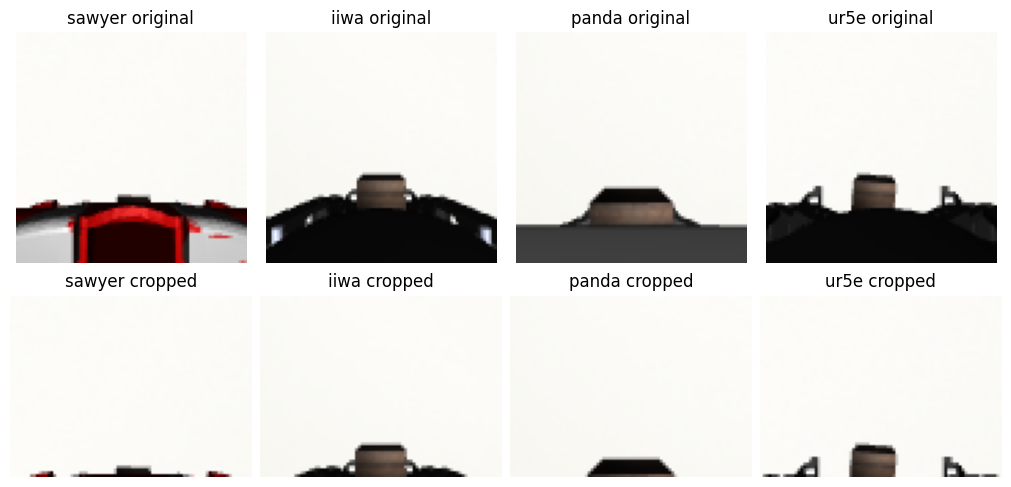

In [26]:
from matplotlib import pyplot as plt 

factor = 0.75
fig, ax = plt.subplots(nrows=2, ncols=len(frames.keys()), figsize=(10, 5), constrained_layout=True)

for i, (key, value) in enumerate(frames.items()):    
    # Top Row: Original Images
    ax[0, i].imshow(value)
    ax[0, i].axis("off")
    ax[0, i].set_title(key+" original")
    
    # Bottom Row: Cropped Images
    h = value.shape[0]
    crop_value = value[:int(h*factor), ...]
    ax[1, i].imshow(crop_value)
    ax[1, i].axis("off")
    ax[1, i].set_title(key+" cropped")

plt.savefig("cropped_obs.jpg")
plt.show()

In [24]:
import torch
from torchvision.models import resnet18 

weight_path = "/home/bing_TUM/ehrensberger/master-thesis/thesis/models/weights/r3m_resnet18_weights.pth"
model = resnet18(weights=torch.load(weight_path))
model = model.eval() 

for frame in frames.values():    
    image = torch.from_numpy(frame)
    image = image.permute(2, 0, 1).unsqueeze(0).to(torch.float32)
    
    h_image = image.shape[2]
    image = image[:, :, :int(h_image*factor), :]

    out = model(image)
    print(out.shape)

/home/bing_TUM/ehrensberger/master-thesis/sim/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
